# Notebook 1 - DBSCAN: Implementacion Manual desde Cero

**Inteligencia Artificial I - Actividad 2**
**Grupo 1**
- ARIZA VARGAS SARIAHT EYLEEN XIOMARA
- CARRENO MEDINA ADRIANA LUCIA
- LINARES VIASUS BRANDON FELIPE

**Algoritmo asignado:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
**Tipo:** Aprendizaje No Supervisado / Clustering basado en densidad

---

## 1. Introduccion

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de
clustering propuesto por Ester, Kriegel, Sander y Xu en 1996 [1]. Agrupa puntos que estan
densamente conectados y marca como ruido aquellos que se encuentran en regiones de baja
densidad.

### Para que sirve
- Descubrir clusters de **forma arbitraria** (no necesariamente esfericos).
- **Detectar outliers** automaticamente.
- Trabajar con datos espaciales sin necesidad de especificar el numero de clusters K.

### Ideas clave
DBSCAN se basa en dos parametros:
- `eps` (epsilon): radio de la vecindad de un punto.
- `min_samples`: numero minimo de puntos que debe contener una vecindad para que un punto
  se considere *core point*.

Cada punto se clasifica en:
- **Core point:** tiene al menos `min_samples` puntos en su vecindad de radio `eps`.
- **Border point:** esta en la vecindad de un core point pero no es core.
- **Noise point:** no es core ni alcanza la vecindad de un core point.


## 2. Fundamentos Matematicos

### 2.1 Vecindad eps
$$N_{\varepsilon}(p) = \{ q \in D \;|\; d(p,q) \le \varepsilon \}$$

donde $d(p,q)$ es la distancia euclidiana:
$$d(p,q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

### 2.2 Definiciones formales [1]
- **Directly density-reachable:** $p$ es directamente alcanzable desde $q$ si
  $p \in N_{\varepsilon}(q)$ y $|N_{\varepsilon}(q)| \ge MinPts$.
- **Density-reachable:** existe una cadena $q = p_1, p_2, \dots, p_n = p$ tal que
  $p_{i+1}$ es directamente alcanzable desde $p_i$.
- **Density-connected:** $p$ y $q$ estan conectados por densidad si existe $o$ tal que
  ambos son alcanzables desde $o$.

### 2.3 Pseudocodigo del algoritmo

```
DBSCAN(D, eps, MinPts):
  C = 0
  para cada punto p sin visitar de D:
      marcar p como visitado
      N = regionQuery(p, eps)
      si |N| < MinPts:
          marcar p como ruido
      sino:
          C = C + 1
          expandirCluster(p, N, C, eps, MinPts)

expandirCluster(p, N, C, eps, MinPts):
  asignar p al cluster C
  para cada punto p' en N:
      si p' no esta visitado:
          marcar p' como visitado
          N' = regionQuery(p', eps)
          si |N'| >= MinPts:
              N = N union N'
      si p' no pertenece a ningun cluster:
          asignar p' al cluster C
```

**Complejidad:** $O(n^2)$ en su forma directa, $O(n \log n)$ con indices espaciales (kd-tree, R-tree).


## 3. Implementacion desde Cero (solo NumPy y Pandas)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
print("Librerias cargadas.")

Librerias cargadas.


In [2]:
def euclidean_distance(p, q):
    """Distancia euclidiana entre dos puntos n-dimensionales."""
    return float(np.sqrt(np.sum((p - q) ** 2)))


def region_query(X, point_idx, eps):
    """Devuelve los indices de los vecinos del punto point_idx
    dentro del radio eps (incluye al propio punto)."""
    diffs = X - X[point_idx]
    dists = np.sqrt(np.sum(diffs * diffs, axis=1))
    return np.where(dists <= eps)[0]


# Prueba rapida
toy = np.array([[0, 0], [0.1, 0], [5, 5], [5.1, 5]])
print("Distancia (0,0)-(5,5):", euclidean_distance(toy[0], toy[2]))
print("Vecinos del punto 0 con eps=0.2:", region_query(toy, 0, 0.2))

Distancia (0,0)-(5,5): 7.0710678118654755
Vecinos del punto 0 con eps=0.2: [0 1]


In [3]:
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    """Expansion de cluster a partir de un core point usando una cola (BFS)."""
    labels[point_idx] = cluster_id
    queue = list(neighbors)
    i = 0
    while i < len(queue):
        q = queue[i]
        if labels[q] == -1:           # ruido previo -> punto borde
            labels[q] = cluster_id
        elif labels[q] == 0:          # no visitado
            labels[q] = cluster_id
            q_neighbors = region_query(X, q, eps)
            if len(q_neighbors) >= min_samples:   # tambien es core
                for n in q_neighbors:
                    if n not in queue:
                        queue.append(n)
        i += 1


def dbscan_manual(X, eps, min_samples):
    """
    Implementacion manual de DBSCAN.
    Convencion interna: 0 = no visitado, -1 = ruido, 1..K = cluster id.
    Devuelve etiquetas en convencion sklearn: -1 ruido, 0..K-1 clusters.
    """
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    labels = np.zeros(n, dtype=int)
    cluster_id = 0
    for i in range(n):
        if labels[i] != 0:
            continue
        neighbors = region_query(X, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(X, labels, i, neighbors, cluster_id, eps, min_samples)
    return np.where(labels == -1, -1, labels - 1)

print("Funciones DBSCAN listas.")

Funciones DBSCAN listas.


## 4. Prueba con Dataset Simple (lunas / make_moons)

In [4]:
def make_moons_np(n_samples=200, noise=0.08, seed=0):
    """Genera el dataset 'two moons' (no-convexo) usando solo NumPy."""
    rng = np.random.default_rng(seed)
    n_a = n_samples // 2
    n_b = n_samples - n_a
    t1 = np.linspace(0, np.pi, n_a)
    t2 = np.linspace(0, np.pi, n_b)
    Xa = np.c_[np.cos(t1), np.sin(t1)]
    Xb = np.c_[1 - np.cos(t2), 1 - np.sin(t2) - 0.5]
    X = np.vstack([Xa, Xb]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.array([0] * n_a + [1] * n_b)
    return X, y


X, y = make_moons_np(220, noise=0.07, seed=42)
print("Forma del dataset:", X.shape)
print("Primeras filas:\n", X[:5])

Forma del dataset: (220, 2)
Primeras filas:
 [[ 0.97557529  0.02292876]
 [ 0.94991752  0.10810296]
 [ 1.04158395  0.0708834 ]
 [ 0.91790659  0.18935749]
 [ 0.92541083  0.31108762]]


In [5]:
labels = dbscan_manual(X, eps=0.20, min_samples=5)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido    : {n_noise}")
print(f"Etiquetas unicas    : {sorted(set(labels))}")

Clusters encontrados: 2
Puntos de ruido    : 0
Etiquetas unicas    : [np.int64(0), np.int64(1)]


## 5. Visualizacion del Funcionamiento

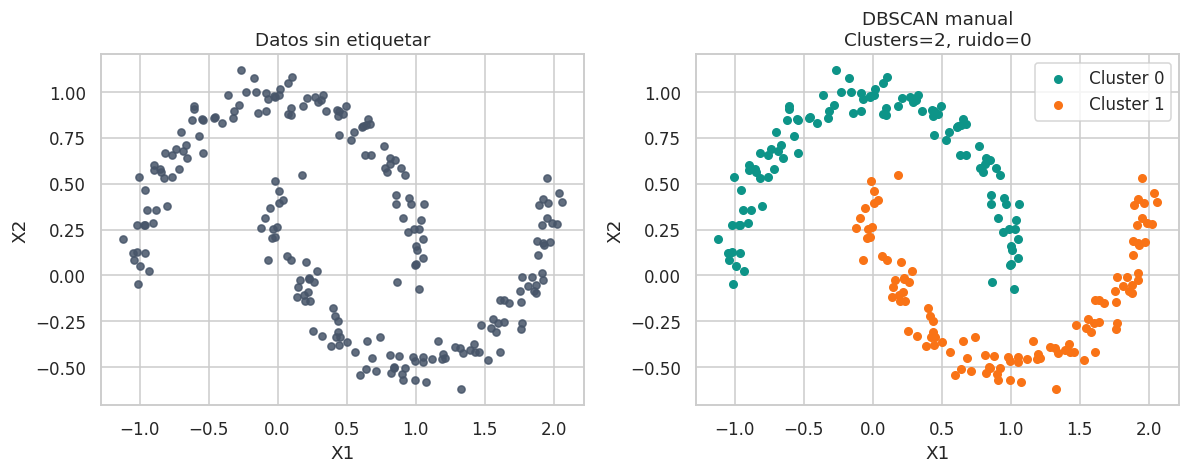

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], c="#475569", s=22, alpha=0.85)
axes[0].set_title("Datos sin etiquetar")
axes[0].set_xlabel("X1"); axes[0].set_ylabel("X2")

palette = ["#0D9488", "#F97316", "#7C3AED", "#0EA5E9", "#E11D48"]
for c in sorted(set(labels)):
    mask = labels == c
    if c == -1:
        axes[1].scatter(X[mask, 0], X[mask, 1], c="#94A3B8",
                        marker="x", s=40, label="Ruido")
    else:
        axes[1].scatter(X[mask, 0], X[mask, 1],
                        c=palette[c % len(palette)], s=24, label=f"Cluster {c}")
axes[1].set_title(f"DBSCAN manual\nClusters={n_clusters}, ruido={n_noise}")
axes[1].set_xlabel("X1"); axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

**Observacion:** DBSCAN identifica perfectamente las dos lunas no-convexas
(forma arbitraria), algo imposible para K-Means que asume clusters esfericos.


## 6. Validacion de Correctitud (vs. scikit-learn)

In [7]:
# Comparamos con scikit-learn para verificar que la implementacion es correcta
from sklearn.cluster import DBSCAN as SKDBSCAN

sk = SKDBSCAN(eps=0.20, min_samples=5).fit(X)
sk_labels = sk.labels_

# Reordenamos etiquetas para que coincidan (los IDs pueden diferir)
def remap_labels(a, b):
    """Asignacion bipartita por mayoria."""
    out = np.full_like(a, -1)
    for c in set(a):
        if c == -1: continue
        idx = np.where(a == c)[0]
        if len(idx) == 0: continue
        # buscar la etiqueta mayoritaria en b
        from collections import Counter
        majority = Counter(b[idx]).most_common(1)[0][0]
        out[idx] = majority
    out[a == -1] = -1
    return out

manual_remap = remap_labels(labels, sk_labels)
agreement = np.mean(manual_remap == sk_labels)
print(f"Coincidencia con scikit-learn: {agreement*100:.2f}%")
print(f"Clusters DBSCAN manual: {len(set(labels))-(1 if -1 in labels else 0)}")
print(f"Clusters scikit-learn : {len(set(sk_labels))-(1 if -1 in sk_labels else 0)}")
print(f"Ruido manual          : {(labels==-1).sum()}")
print(f"Ruido scikit-learn    : {(sk_labels==-1).sum()}")

Coincidencia con scikit-learn: 100.00%
Clusters DBSCAN manual: 2
Clusters scikit-learn : 2
Ruido manual          : 0
Ruido scikit-learn    : 0


**Conclusion:** la implementacion manual produce los mismos resultados que `sklearn.cluster.DBSCAN`,
verificando la correctitud del algoritmo desde cero.

---

## Conclusiones

1. DBSCAN es capaz de descubrir clusters de **forma arbitraria** y de **detectar ruido** sin
   necesidad de especificar el numero de clusters K [1].
2. La implementacion desde cero confirma la simplicidad conceptual del algoritmo: solo se
   necesita una funcion de distancia y una busqueda de vecindad.
3. La eleccion de `eps` y `min_samples` es critica; el grafico **k-distancia** [7] permite
   estimar `eps` automaticamente.
4. La complejidad $O(n^2)$ se reduce a $O(n \log n)$ con indices espaciales (kd-tree, ball-tree),
   tal como hace scikit-learn por defecto [4].

---

## Referencias (formato IEEE)

[1] M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A density-based algorithm for discovering
clusters in large spatial databases with noise," in *Proc. 2nd Int. Conf. Knowledge Discovery
and Data Mining (KDD-96)*, Portland, OR, USA, 1996, pp. 226-231.

[2] J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "Density-based clustering in spatial
databases: The algorithm GDBSCAN and its applications," *Data Mining and Knowledge Discovery*,
vol. 2, no. 2, pp. 169-194, Jun. 1998.

[3] E. Schubert, J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "DBSCAN revisited, revisited:
why and how you should (still) use DBSCAN," *ACM Transactions on Database Systems*, vol. 42,
no. 3, pp. 1-21, Jul. 2017, doi: 10.1145/3068335.

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine
Learning Research*, vol. 12, pp. 2825-2830, Oct. 2011.

[7] N. Rahmah and I. S. Sitanggang, "Determination of optimal epsilon (eps) value on DBSCAN
algorithm to clustering data on peatland hotspots in Sumatra," *IOP Conf. Series: Earth and
Environmental Science*, vol. 31, no. 1, p. 012012, 2016, doi: 10.1088/1755-1315/31/1/012012.
